# Bagel Demand Forecast — inspection

The pilot's human-eyeball surface. It answers two questions the MAPE table alone can't:

1. **Do the charts look like bagel sales?** Weekend peaks in the right place, magnitudes sane.
2. **Does the seasonal-naive model beat a dumber baseline** — a trailing 7-day moving average — over
   the same held-out days?

Everything below reads `data/sales_history.parquet` and replays `forecast.forecast_demand` over the
last four weeks as if they were still in the future. No forecast here ever sees the day it forecasts;
see `backtest.py`'s module docstring for how the replay origins guarantee that.

Run `.venv/bin/pip install -e '.[notebook]'` first if matplotlib is missing.


In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

sys.path.insert(0, "..")
import backtest
import forecast
import sales_history

sales = sales_history.load_sales_history()
holdout_start, holdout_end = backtest.holdout_window(sales)
comparison = backtest.compare(sales)

print(f"Sales history: {sales['date'].min():%Y-%m-%d} .. {sales['date'].max():%Y-%m-%d}")
print(f"held out:      {holdout_start:%Y-%m-%d} .. {holdout_end:%Y-%m-%d}")
print(f"origins:       {', '.join(str(o) for o in backtest.replay_origins(holdout_start, holdout_end))}")
comparison.head()


Sales history: 2024-03-01 .. 2026-07-09
held out:      2026-06-12 .. 2026-07-09
origins:       2026-06-10, 2026-06-16, 2026-06-22, 2026-06-28, 2026-07-04


,product,date,actual,seasonal_naive,moving_average,comparable,scored
0,everything,2026-06-12,181.0,188.495798,194.857143,True,True
1,gluten-free everything,2026-06-12,7.0,7.840336,6.857143,True,True
2,gluten-free plain,2026-06-12,8.0,5.495726,6.142857,True,True
3,plain,2026-06-12,137.0,119.245763,146.285714,True,True
4,sesame,2026-06-12,106.0,117.815126,113.428571,True,True


## Accuracy over the holdout

MAPE, lower is better. `scored` counts the (Product, day) pairs the metric could actually use: a day
with zero actual Sales has no percentage error, and a day the seasonal-naive model declined to
forecast is dropped from *both* models so the two are compared on identical rows.


In [2]:
products = backtest.product_scores(comparison).set_index("product")
products.style.format({
    "seasonal_naive_mape": "{:.1f}%",
    "moving_average_mape": "{:.1f}%",
}).background_gradient(subset=["seasonal_naive_mape", "moving_average_mape"], cmap="Reds")


,scored_days,unscored_days,seasonal_naive_mape,moving_average_mape
product,,,,
everything,24,0,14.3%,35.4%
gluten-free everything,24,0,65.8%,55.9%
gluten-free plain,24,0,64.2%,99.9%
plain,24,0,17.6%,33.6%
sesame,24,0,18.8%,30.2%


In [3]:
family = backtest.family_totals(comparison)
scores = backtest.family_scores(comparison)

print(f"family Sales Forecast, {scores['scored_days']} scored days")
print(f"  seasonal-naive:  {scores['seasonal_naive_mape']:.1f}% MAPE")
print(f"  moving-average:  {scores['moving_average_mape']:.1f}% MAPE  (baseline)")

bias = (family["seasonal_naive"] - family["actual"]).mean()
print(f"\nmean bias: {bias:+.1f} units/day on a mean actual of {family['actual'].mean():.1f}")
print("(positive = over-forecast, which costs waste rather than a stockout)")


family Sales Forecast, 24 scored days
  seasonal-naive:  12.5% MAPE
  moving-average:  31.0% MAPE  (baseline)

mean bias: +16.0 units/day on a mean actual of 444.7
(positive = over-forecast, which costs waste rather than a stockout)


## Forecast vs. actual, per Product

Black is actual Sales. Blue is the seasonal-naive Demand Forecast; grey is the moving-average
baseline. Amber bands are weekends — the shape to check is that the black line peaks inside them.

Both locations were closed for four days around Saturday July 4th, 2026 (the grey band). Those days
carry no Sales record and the backtest never scores them, so the lines are broken across the gap
rather than interpolated through it — a line drawn straight from July 2nd to July 7th would invent a
weekend that never happened.


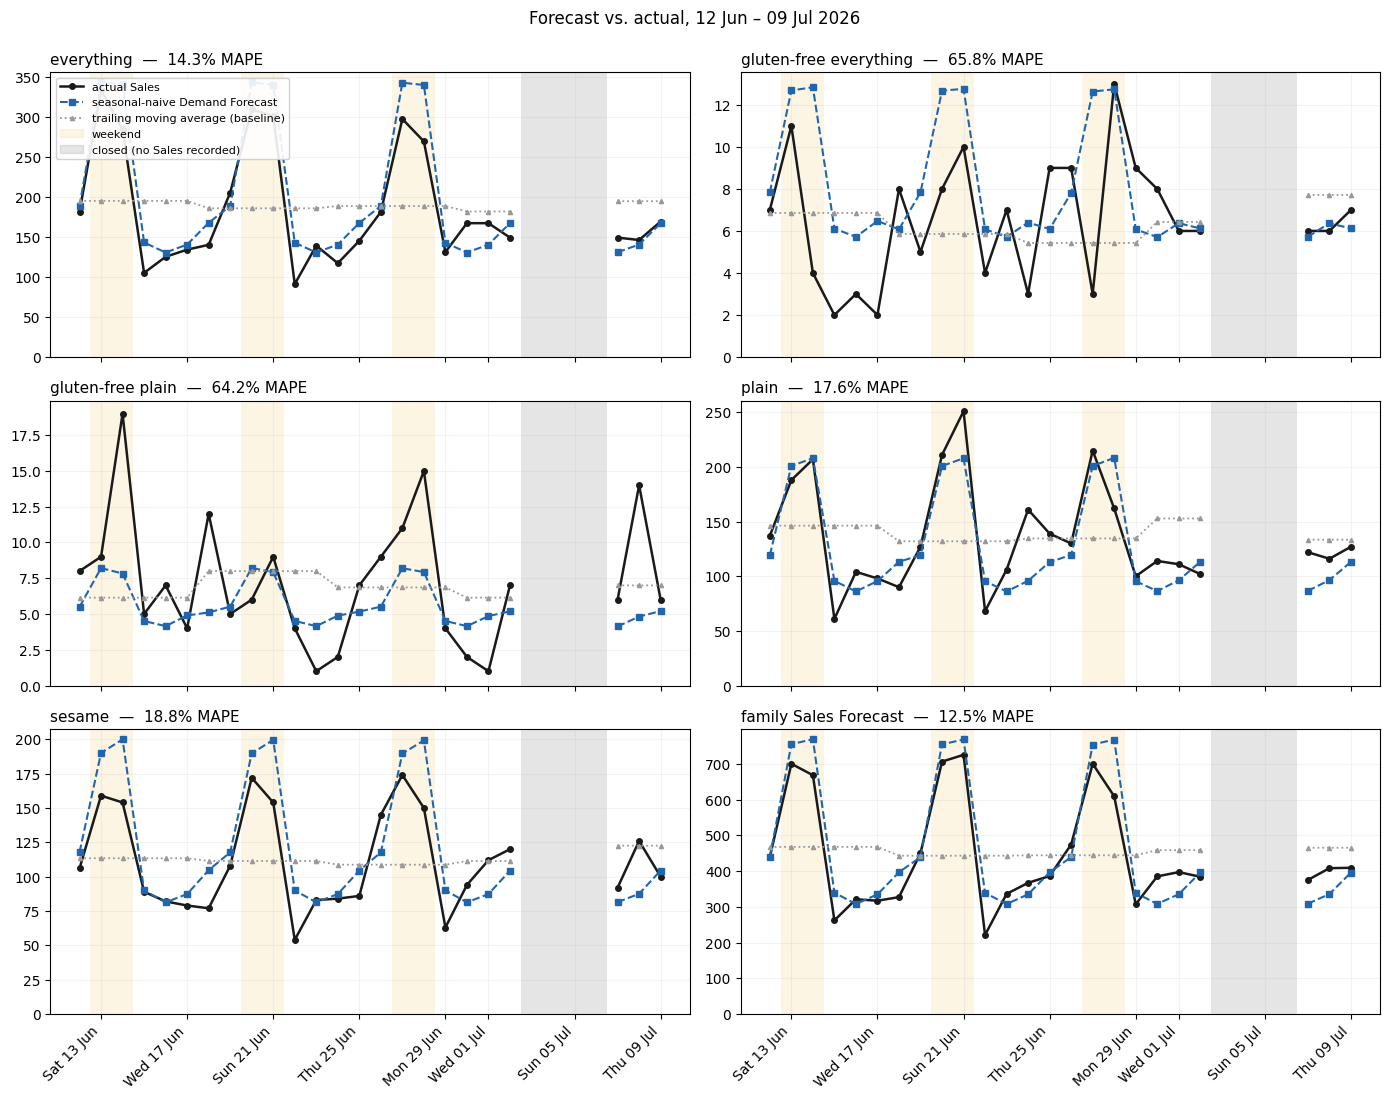

In [4]:
from matplotlib.patches import Patch

calendar = pd.date_range(holdout_start, holdout_end, freq="D")
closed_days = sorted(set(calendar) - set(comparison["date"]))


def on_calendar(frame):
    """Reindex onto every calendar day so closed days become NaN, and matplotlib
    breaks the line there instead of drawing through the closure."""
    return frame.set_index("date").reindex(calendar).rename_axis("date").reset_index()


def shade(ax):
    for day in calendar:
        if day in closed_days:
            color, alpha = "#8c8c8c", 0.22
        elif day.dayofweek >= 5:
            color, alpha = "#f0b429", 0.12
        else:
            continue
        ax.axvspan(day - pd.Timedelta(hours=12), day + pd.Timedelta(hours=12),
                   color=color, alpha=alpha, lw=0)


def plot_series(ax, frame, title):
    frame = on_calendar(frame)
    ax.plot(frame["date"], frame["actual"], "o-", color="#1a1a1a", lw=1.8, ms=4, label="actual Sales")
    ax.plot(frame["date"], frame["seasonal_naive"], "s--", color="#2166ac", lw=1.5, ms=4,
            label="seasonal-naive Demand Forecast")
    ax.plot(frame["date"], frame["moving_average"], "^:", color="#999999", lw=1.3, ms=3,
            label="trailing moving average (baseline)")
    shade(ax)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.15)


panels = sorted(comparison["product"].unique())
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)

for ax, product in zip(axes.flat, panels):
    series = comparison[comparison["product"] == product].sort_values("date")
    mape = backtest.mape(series.loc[series["scored"], "actual"],
                         series.loc[series["scored"], "seasonal_naive"])
    plot_series(ax, series, f"{product}  —  {mape:.1f}% MAPE")

plot_series(axes.flat[len(panels)], family,
            f"family Sales Forecast  —  {scores['seasonal_naive_mape']:.1f}% MAPE")

handles, labels = axes.flat[0].get_legend_handles_labels()
handles += [Patch(color="#f0b429", alpha=0.12), Patch(color="#8c8c8c", alpha=0.22)]
labels += ["weekend", "closed (no Sales recorded)"]
axes.flat[0].legend(handles, labels, loc="upper left", fontsize=8, framealpha=0.9)

for ax in axes[-1]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle(f"Forecast vs. actual, {holdout_start:%d %b} – {holdout_end:%d %b %Y}", y=0.995)
fig.tight_layout()
plt.show()


## Is the weekly shape real?

The model's whole premise is that a Product's weekday is the dominant signal. If it is, actual Sales
should climb into the weekend, and the seasonal-naive forecast should climb with it.


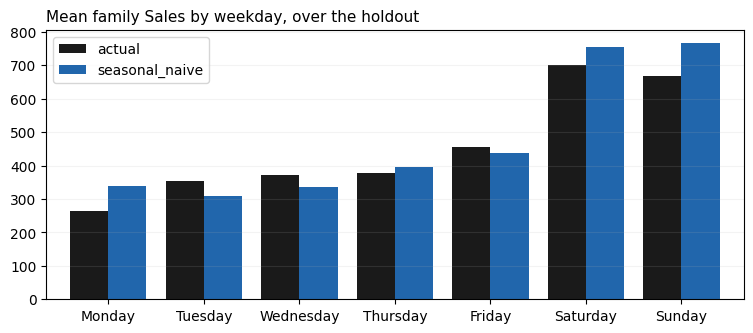

,actual,seasonal_naive,days
weekday,,,
Monday,263.3,338.9,3
Tuesday,354.2,308.0,4
Wednesday,372.2,335.1,4
Thursday,376.5,396.1,4
Friday,454.3,438.9,3
Saturday,702.0,754.2,3
Sunday,667.3,768.2,3


In [5]:
ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
labelled = family.assign(weekday=family["date"].dt.day_name())

by_weekday = labelled.groupby("weekday")[["actual", "seasonal_naive"]].mean().reindex(ORDER)
by_weekday["days"] = labelled.groupby("weekday").size().reindex(ORDER)
by_weekday = by_weekday.dropna()

ax = by_weekday[["actual", "seasonal_naive"]].plot.bar(
    figsize=(9, 3.5), color=["#1a1a1a", "#2166ac"], width=0.8, rot=0
)
ax.set_title("Mean family Sales by weekday, over the holdout", fontsize=11, loc="left")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.15)
plt.show()

# `days` is the sample behind each bar — the July 4th closure costs Friday
# through Monday one observation each, so those bars rest on three days, not four.
by_weekday.round(1)


## Conclusion

**Yes, seasonal-naive beats the baseline, and the forecast is plausible.** Both parts of the pilot's
accuracy question come out on the right side, with one honest caveat.

**It beats the baseline where it counts.** On the family-level Sales Forecast the seasonal-naive
model scores **12.5% MAPE against the baseline's 31.0%** — the trailing moving average, having no
notion of weekday, spends every weekend under-forecasting and every Monday over-forecasting. Per
Product it wins on four of five: `everything` (14.3% vs 35.4%), `plain` (17.6% vs 33.6%), `sesame`
(18.8% vs 30.2%), and `gluten-free plain` (64.2% vs 99.9%).

**It loses on `gluten-free everything`** (65.8% vs 55.9%). That Product sells ~8 units/day, so a
two-unit miss is a 25% error and MAPE is measuring noise more than seasonality. The same is true of
`gluten-free plain`'s 64.2%: both gluten-free lines have percentage errors an order of magnitude
worse than the three high-volume varieties, and neither number should be read as a statement about
the model. They are a statement about dividing by four.

**The shape is right.** Every per-Product panel peaks inside the amber weekend bands, and the blue
forecast peaks with it — the weekend is where the model earns its 2× win over the baseline, whose
flat grey line simply misses it. The family climbs from ~263 units on a Monday to ~700 on a Saturday.
Magnitudes are sane: ~200–310 `everything` bagels on a weekend day against ~110–150 midweek. Mean
bias is **+16 units/day on a mean actual of 445** (about 3.6% over-forecast) — the safe direction for
a bakery, since it costs waste rather than a stockout.

**Where it misses, it misses on Mondays.** The three worst family days in the holdout are 2026-06-22
(221 actual vs 339 forecast, 53% high), 2026-06-15 (29% high), and Sunday 2026-06-28 (26% high). Two
of three are Mondays, and both over-forecast: the two-year Monday mean sits well above recent
Mondays. A model with any trend term would catch that, and per the PRD that is deferred.

**Verdict for the pilot: the pipeline is sound and the forecast is in the right ballpark.** A 12.5%
family MAPE from a five-line model, beating a real baseline by better than 2×, clears the
"plumbing-and-shape" bar the PRD set. The gluten-free lines and the Monday drift are the two things
worth a look before anyone tunes for accuracy.
